In [ ]:
# ============================================
# 0. SETUP: Imports & Display Options
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/charts.csv')

In [ ]:
df.head()

,date,rank,song,artist,last-week,peak-rank,weeks-on-board
0,2021-11-06,1,Easy On Me,Adele,1.0,1,3
1,2021-11-06,2,Stay,The Kid LAROI & Justin Bieber,2.0,1,16
2,2021-11-06,3,Industry Baby,Lil Nas X & Jack Harlow,3.0,1,14
3,2021-11-06,4,Fancy Like,Walker Hayes,4.0,3,19
4,2021-11-06,5,Bad Habits,Ed Sheeran,5.0,2,18


In [ ]:
# ============================================
# 2. QUICK DATA OVERVIEW
# ============================================
print("\n--- Info ---")
df.info()

print("\n--- Nulls per column ---")
print(df.isna().sum())

print("\n--- Sample rows ---")
display(df.sample(5))



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330087 entries, 0 to 330086
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            330087 non-null  object 
 1   rank            330087 non-null  int64  
 2   song            330087 non-null  object 
 3   artist          330087 non-null  object 
 4   last-week       297775 non-null  float64
 5   peak-rank       330087 non-null  int64  
 6   weeks-on-board  330087 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 17.6+ MB

--- Nulls per column ---
date                  0
rank                  0
song                  0
artist                0
last-week         32312
peak-rank             0
weeks-on-board        0
dtype: int64

--- Sample rows ---


,date,rank,song,artist,last-week,peak-rank,weeks-on-board
175491,1988-03-26,92,Never Can Say Goodbye,The Communards,88.0,51,9
122785,1998-05-02,86,Sweet Surrender,Sarah McLachlan,83.0,28,12
179215,1987-07-04,16,"Girls, Girls, Girls",Motley Crue,19.0,16,6
306721,1963-01-26,35,Rhythm Of The Rain,The Cascades,65.0,35,3
52643,2011-10-08,44,Take Over Control,Afrojack Featuring Eva Simons,41.0,41,15


In [ ]:
# ============================================
# 3. CLEAN COLUMN NAMES
#    (replace '-' with '_' etc.)
# ============================================
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

print("Columns:", df.columns.tolist())


Columns: ['date', 'rank', 'song', 'artist', 'last_week', 'peak_rank', 'weeks_on_board']


In [ ]:
# ============================================
# 4. BASIC CLEANING
#    - drop duplicates
#    - convert types
# ============================================

# 4.1 drop exact duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Dropped {before - after} duplicate rows")

# 4.2 convert date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())

# 4.3 convert numeric columns
num_cols = ["rank", "last_week", "peak_rank", "weeks_on_board"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        print(f"{col}: converted to numeric")

print("\nNull counts after conversions:")
print(df.isna().sum())


Dropped 0 duplicate rows
Min date: 1958-08-04 00:00:00
Max date: 2021-11-06 00:00:00
rank: converted to numeric
last_week: converted to numeric
peak_rank: converted to numeric
weeks_on_board: converted to numeric

Null counts after conversions:
date                  0
rank                  0
song                  0
artist                0
last_week         32312
peak_rank             0
weeks_on_board        0
dtype: int64


In [ ]:
# ============================================
# 5. FEATURE ENGINEERING
#    - year, month, decade
#    - is_collab (feat., ft., &, x)
# ============================================

# 5.1 year / month / decade
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["decade"] = (df["year"] // 10) * 10

# 5.2 collaboration flag from song + artist strings
def detect_collab(row):
    text = ""
    if isinstance(row["song"], str):
        text += row["song"].lower()
    if isinstance(row["artist"], str):
        text += " " + row["artist"].lower()
    return int(
        ("feat." in text)
        or ("ft." in text)
        or (" feat " in text)
        or (" ft " in text)
        or (" & " in text)
        or (" x " in text)
    )

df["is_collab"] = df.apply(detect_collab, axis=1)

df.head()


,date,rank,song,artist,last_week,peak_rank,weeks_on_board,year,month,decade,is_collab
0,2021-11-06,1,Easy On Me,Adele,1.0,1,3,2021,11,2020,0
1,2021-11-06,2,Stay,The Kid LAROI & Justin Bieber,2.0,1,16,2021,11,2020,1
2,2021-11-06,3,Industry Baby,Lil Nas X & Jack Harlow,3.0,1,14,2021,11,2020,1
3,2021-11-06,4,Fancy Like,Walker Hayes,4.0,3,19,2021,11,2020,0
4,2021-11-06,5,Bad Habits,Ed Sheeran,5.0,2,18,2021,11,2020,0


In [ ]:
# ============================================
# 6. GLOBAL SUMMARY STATS
# ============================================

print("\n--- Time Coverage ---")
print("Years:", df["year"].min(), "to", df["year"].max())

print("\n--- Unique Songs & Artists ---")
print("Unique songs :", df["song"].nunique())
print("Unique artists:", df["artist"].nunique())

print("\n--- Rank Summary ---")
print(df["rank"].describe())

print("\n--- Weeks on Board Summary ---")
print(df["weeks_on_board"].describe())



--- Time Coverage ---
Years: 1958 to 2021

--- Unique Songs & Artists ---
Unique songs : 24620
Unique artists: 10205

--- Rank Summary ---
count    330087.000000
mean         50.500929
std          28.866094
min           1.000000
25%          26.000000
50%          51.000000
75%          76.000000
max         100.000000
Name: rank, dtype: float64

--- Weeks on Board Summary ---
count    330087.000000
mean          9.161785
std           7.618264
min           1.000000
25%           4.000000
50%           7.000000
75%          13.000000
max          90.000000
Name: weeks_on_board, dtype: float64


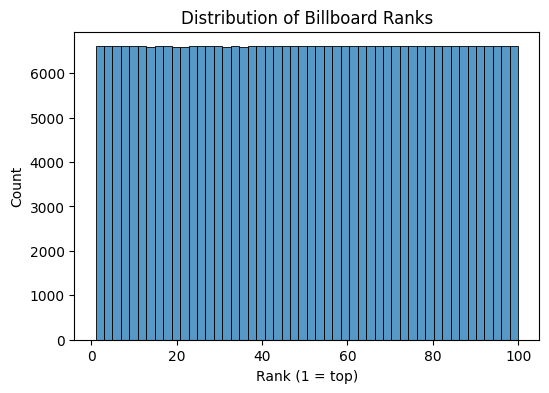

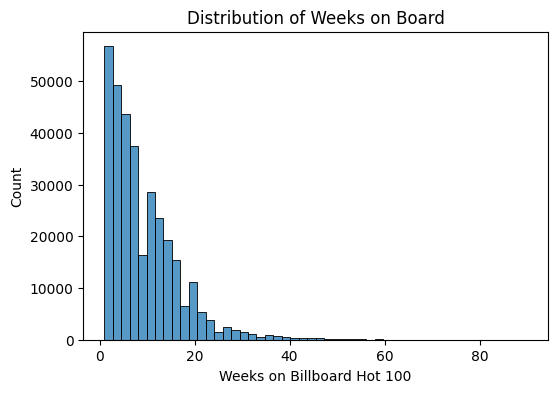

In [ ]:
# ============================================
# 7. BASIC DISTRIBUTIONS
# ============================================

# 7.1 rank distribution
plt.figure(figsize=(6,4))
sns.histplot(df["rank"].dropna(), bins=50)
plt.title("Distribution of Billboard Ranks")
plt.xlabel("Rank (1 = top)")
plt.ylabel("Count")
plt.show()

# 7.2 weeks_on_board distribution
plt.figure(figsize=(6,4))
sns.histplot(df["weeks_on_board"].dropna(), bins=50)
plt.title("Distribution of Weeks on Board")
plt.xlabel("Weeks on Billboard Hot 100")
plt.ylabel("Count")
plt.show()


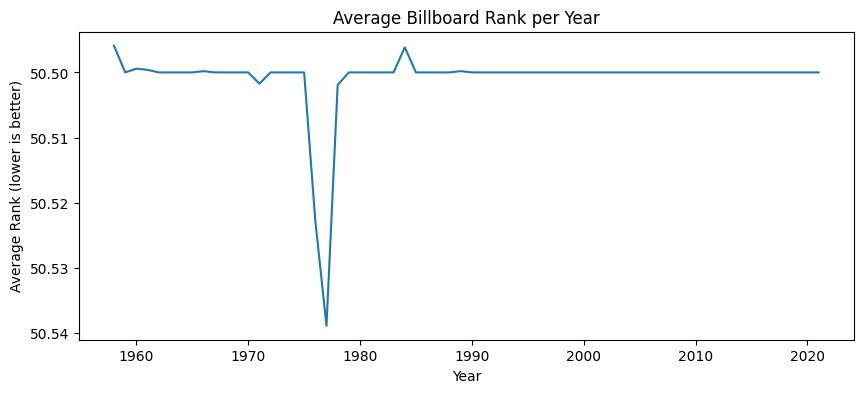

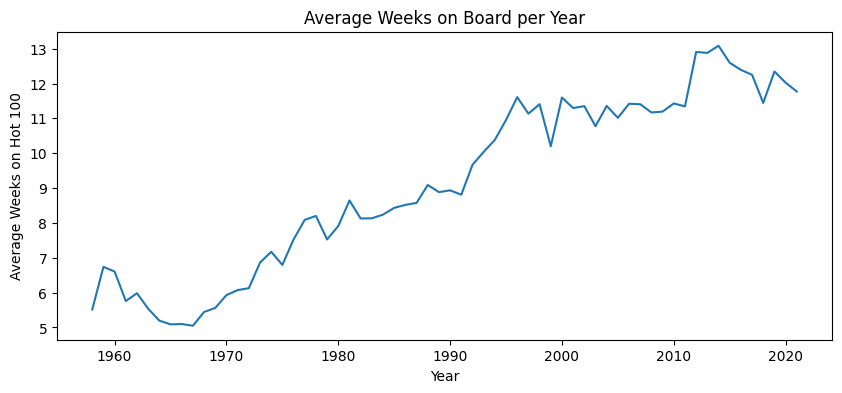

In [ ]:
# ============================================
# 8. TIME TRENDS BY YEAR
#    - average rank
#    - average weeks on board
# ============================================

yearly_rank = df.groupby("year")["rank"].mean().reset_index()
yearly_weeks = df.groupby("year")["weeks_on_board"].mean().reset_index()

# 8.1 average rank per year
plt.figure(figsize=(10,4))
sns.lineplot(data=yearly_rank, x="year", y="rank")
plt.gca().invert_yaxis()   # 1 is best
plt.title("Average Billboard Rank per Year")
plt.xlabel("Year")
plt.ylabel("Average Rank (lower is better)")
plt.show()

# 8.2 average weeks_on_board per year
plt.figure(figsize=(10,4))
sns.lineplot(data=yearly_weeks, x="year", y="weeks_on_board")
plt.title("Average Weeks on Board per Year")
plt.xlabel("Year")
plt.ylabel("Average Weeks on Hot 100")
plt.show()


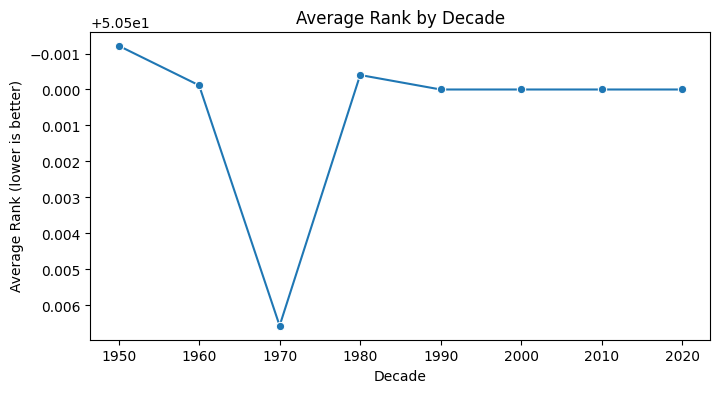

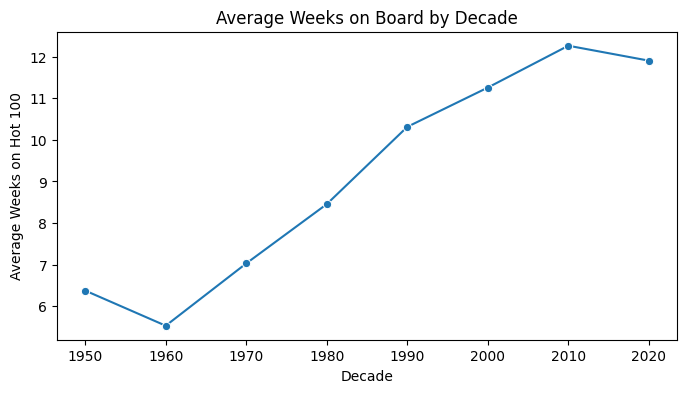

In [ ]:
# ============================================
# 9. DECADE-LEVEL VIEW
# ============================================

decade_rank = df.groupby("decade")["rank"].mean().reset_index()
decade_weeks = df.groupby("decade")["weeks_on_board"].mean().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(data=decade_rank, x="decade", y="rank", marker="o")
plt.gca().invert_yaxis()
plt.title("Average Rank by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Rank (lower is better)")
plt.show()

plt.figure(figsize=(8,4))
sns.lineplot(data=decade_weeks, x="decade", y="weeks_on_board", marker="o")
plt.title("Average Weeks on Board by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Weeks on Hot 100")
plt.show()


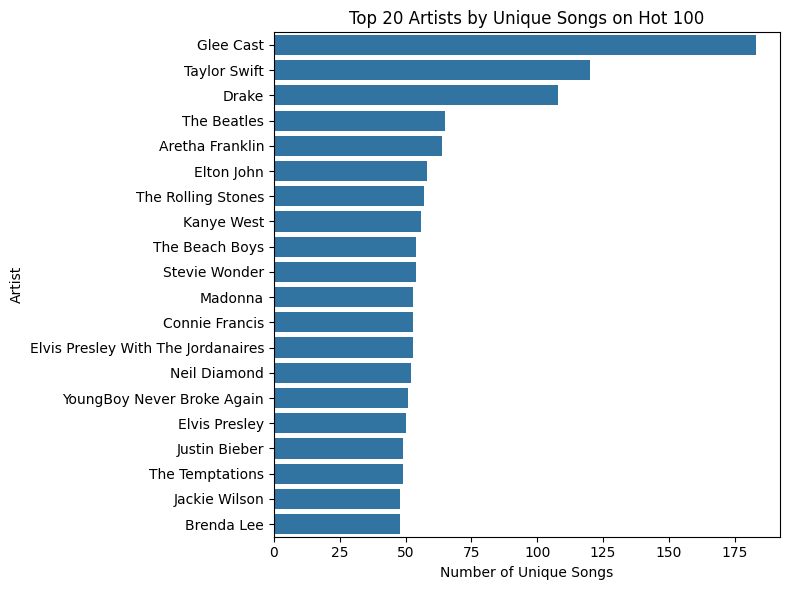

Number of one-hit-wonder artists: 6618


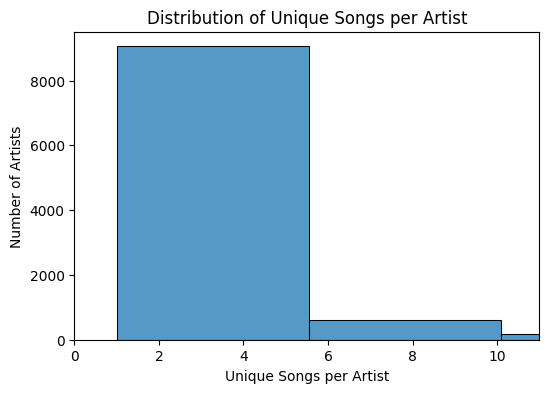

In [ ]:
# ============================================
# 10. TOP ARTISTS & ONE-HIT WONDERS
# ============================================

# unique songs per artist
artist_song_counts = (
    df.groupby("artist")["song"]
      .nunique()
      .reset_index()
      .rename(columns={"song": "unique_songs"})
)

# top 20 artists
top_artists = artist_song_counts.sort_values("unique_songs", ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(data=top_artists, x="unique_songs", y="artist")
plt.title("Top 20 Artists by Unique Songs on Hot 100")
plt.xlabel("Number of Unique Songs")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

# one-hit wonders = exactly 1 unique song
one_hit_wonders = artist_song_counts[artist_song_counts["unique_songs"] == 1]
print("Number of one-hit-wonder artists:", len(one_hit_wonders))

plt.figure(figsize=(6,4))
sns.histplot(artist_song_counts["unique_songs"], bins=40)
plt.title("Distribution of Unique Songs per Artist")
plt.xlabel("Unique Songs per Artist")
plt.ylabel("Number of Artists")
plt.xlim(0, artist_song_counts["unique_songs"].quantile(0.95))  # zoom in
plt.show()


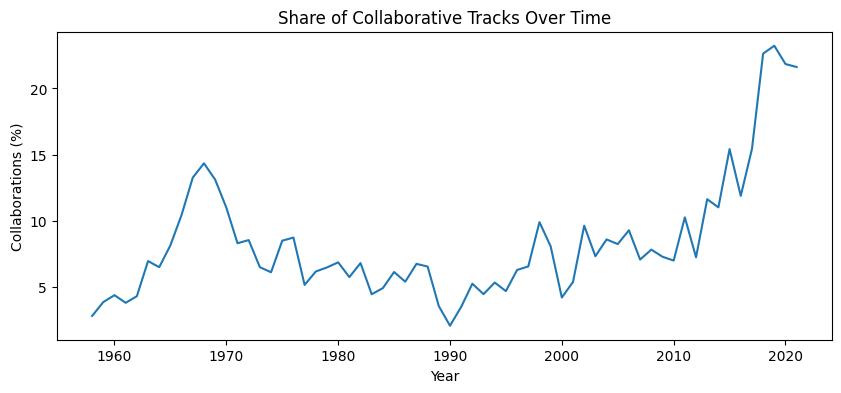

In [ ]:
# ============================================
# 11. COLLABORATION TRENDS OVER TIME
# ============================================

collab_yearly = (
    df.groupby("year")["is_collab"]
      .mean()
      .reset_index()
      .rename(columns={"is_collab": "collab_rate"})
)
collab_yearly["collab_percent"] = collab_yearly["collab_rate"] * 100

plt.figure(figsize=(10,4))
sns.lineplot(data=collab_yearly, x="year", y="collab_percent")
plt.title("Share of Collaborative Tracks Over Time")
plt.xlabel("Year")
plt.ylabel("Collaborations (%)")
plt.show()


In [ ]:
# ============================================
# 12. TOP SONGS BY LONGEVITY
# ============================================

top_longevity = (
    df.sort_values("weeks_on_board", ascending=False)
      .drop_duplicates(subset=["song", "artist"])
      .head(20)
      [["song", "artist", "weeks_on_board", "peak_rank"]]
)

display(top_longevity)


,song,artist,weeks_on_board,peak_rank
919,Blinding Lights,The Weeknd,90,1
39148,Radioactive,Imagine Dragons,87,3
39844,Sail,AWOLNATION,79,17
63047,I'm Yours,Jason Mraz,76,6
120444,How Do I Live,LeAnn Rimes,69,2
36849,Counting Stars,OneRepublic,68,2
48548,Party Rock Anthem,LMFAO Featuring Lauren Bennett & GoonRock,68,1
49948,Rolling In The Deep,Adele,65,1
123746,Foolish Games/You Were Meant For Me,Jewel,65,2
72746,Before He Cheats,Carrie Underwood,64,8


1. Number of Songs per Year (Chart Volume Trend)

   Shows how the total chart entries change over time - great opener.

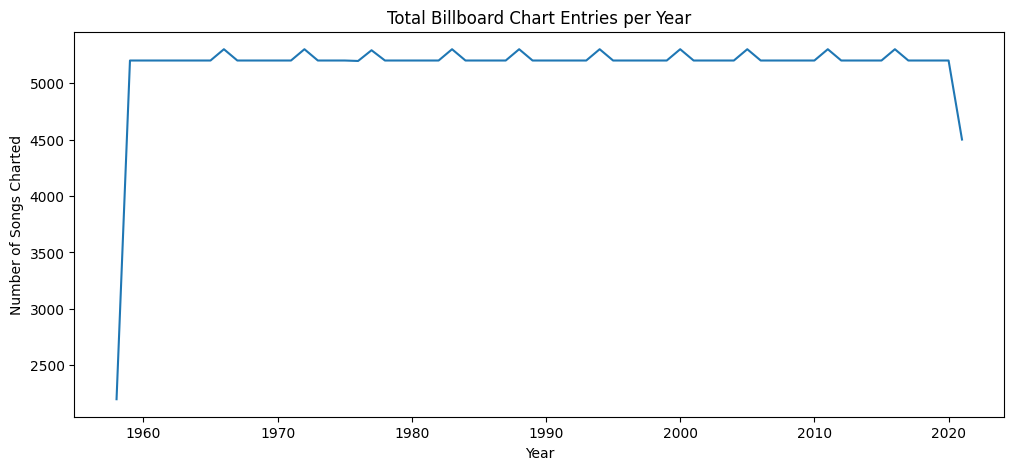

In [ ]:
songs_per_year = df.groupby("year")["song"].count().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=songs_per_year, x="year", y="song")
plt.title("Total Billboard Chart Entries per Year")
plt.xlabel("Year")
plt.ylabel("Number of Songs Charted")
plt.show()


2. Average Billboard Rank per Year

   How hard it is to chart over time.

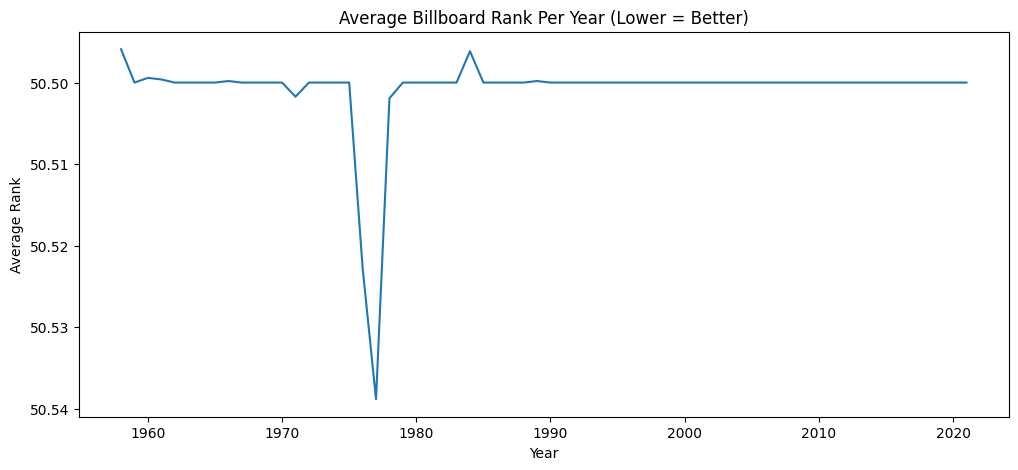

In [ ]:
yearly_rank = df.groupby("year")["rank"].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=yearly_rank, x="year", y="rank")
plt.gca().invert_yaxis()
plt.title("Average Billboard Rank Per Year (Lower = Better)")
plt.xlabel("Year")
plt.ylabel("Average Rank")
plt.show()


3. Average Weeks on Chart per Year (Longevity Trend)

   Shows rise/fall of staying power.

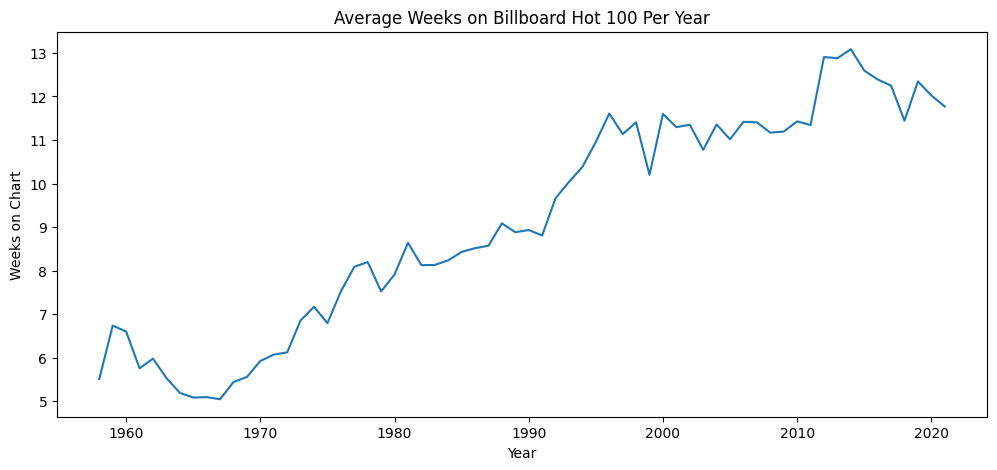

In [ ]:
yearly_weeks = df.groupby("year")["weeks_on_board"].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=yearly_weeks, x="year", y="weeks_on_board")
plt.title("Average Weeks on Billboard Hot 100 Per Year")
plt.xlabel("Year")
plt.ylabel("Weeks on Chart")
plt.show()


4. Decade-Level Longevity Comparison

   Perfect for storytelling (Boomers → Gen X → Millennials → Gen Z).

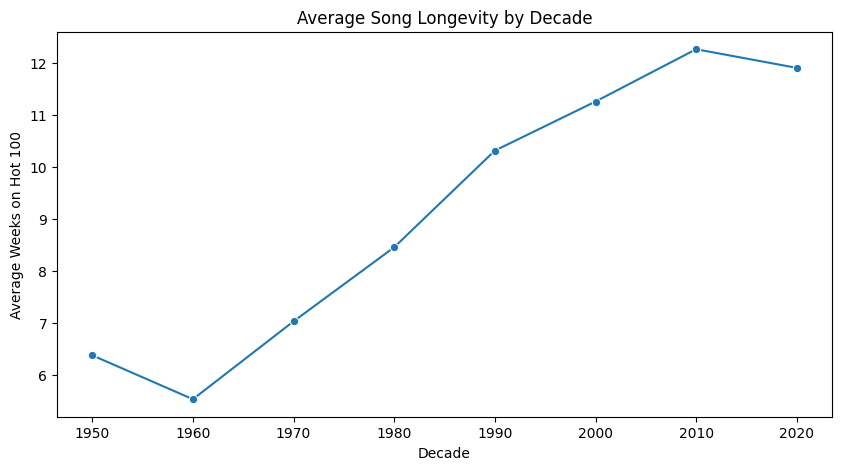

In [ ]:
decade_stats = df.groupby("decade")["weeks_on_board"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=decade_stats, x="decade", y="weeks_on_board", marker="o")
plt.title("Average Song Longevity by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Weeks on Hot 100")
plt.show()


5. Collaboration Trend: % “feat.” Songs Over Time

   Shows how collabs exploded after 2000 and even more after 2016.

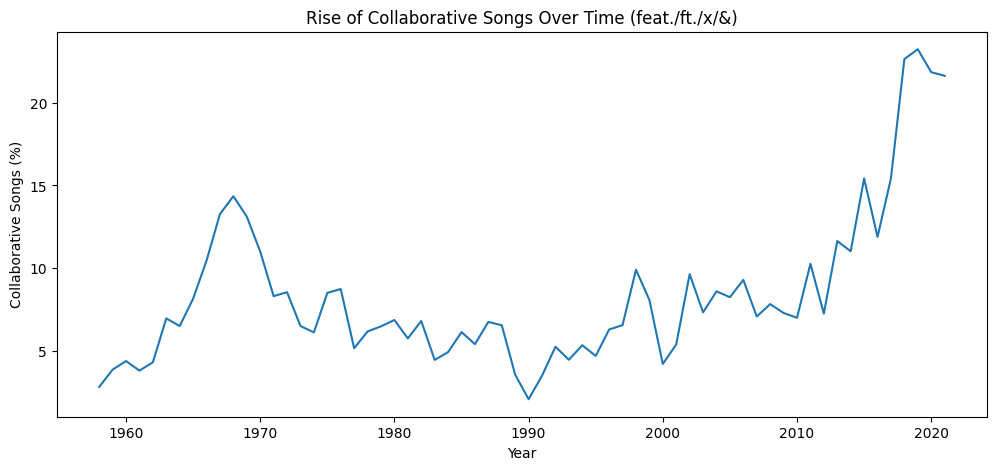

In [ ]:
collab_yearly = (
    df.groupby("year")["is_collab"]
      .mean()
      .reset_index()
      .rename(columns={"is_collab": "collab_rate"})
)

collab_yearly["collab_percent"] = collab_yearly["collab_rate"] * 100

plt.figure(figsize=(12,5))
sns.lineplot(data=collab_yearly, x="year", y="collab_percent")
plt.title("Rise of Collaborative Songs Over Time (feat./ft./x/&)")
plt.xlabel("Year")
plt.ylabel("Collaborative Songs (%)")
plt.show()


6. Top 20 Artists of All Time (Unique Songs)

   Amazing bar chart for the showcase

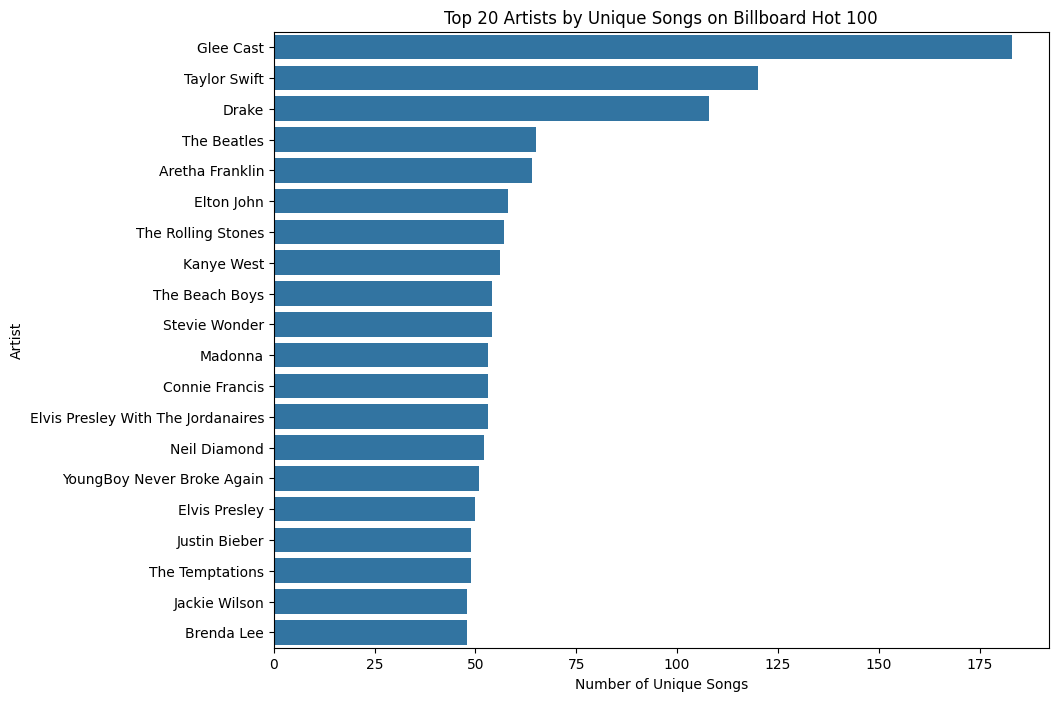

In [ ]:
artist_song_counts = (
    df.groupby("artist")["song"]
      .nunique()
      .reset_index()
      .rename(columns={"song": "unique_songs"})
)

top20_artists = artist_song_counts.sort_values("unique_songs", ascending=False).head(20)

plt.figure(figsize=(10,8))
sns.barplot(data=top20_artists, x="unique_songs", y="artist")
plt.title("Top 20 Artists by Unique Songs on Billboard Hot 100")
plt.xlabel("Number of Unique Songs")
plt.ylabel("Artist")
plt.show()


7. One-Hit Wonder Distribution

   Shows how many artists chart only once.

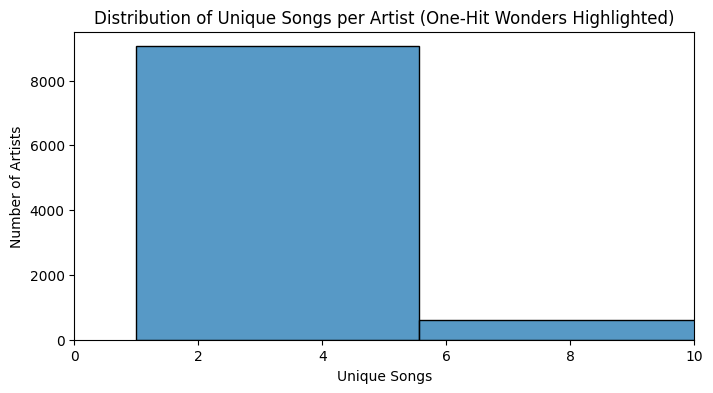

Total one-hit-wonder artists: 6618


In [ ]:
one_hit = artist_song_counts[artist_song_counts["unique_songs"] == 1]

plt.figure(figsize=(8,4))
sns.histplot(artist_song_counts["unique_songs"], bins=40)
plt.title("Distribution of Unique Songs per Artist (One-Hit Wonders Highlighted)")
plt.xlabel("Unique Songs")
plt.ylabel("Number of Artists")
plt.xlim(0, 10)
plt.show()

print("Total one-hit-wonder artists:", len(one_hit))


8. Top 20 Longest-Charting Songs of All Time

   This is always popular the popular songs.

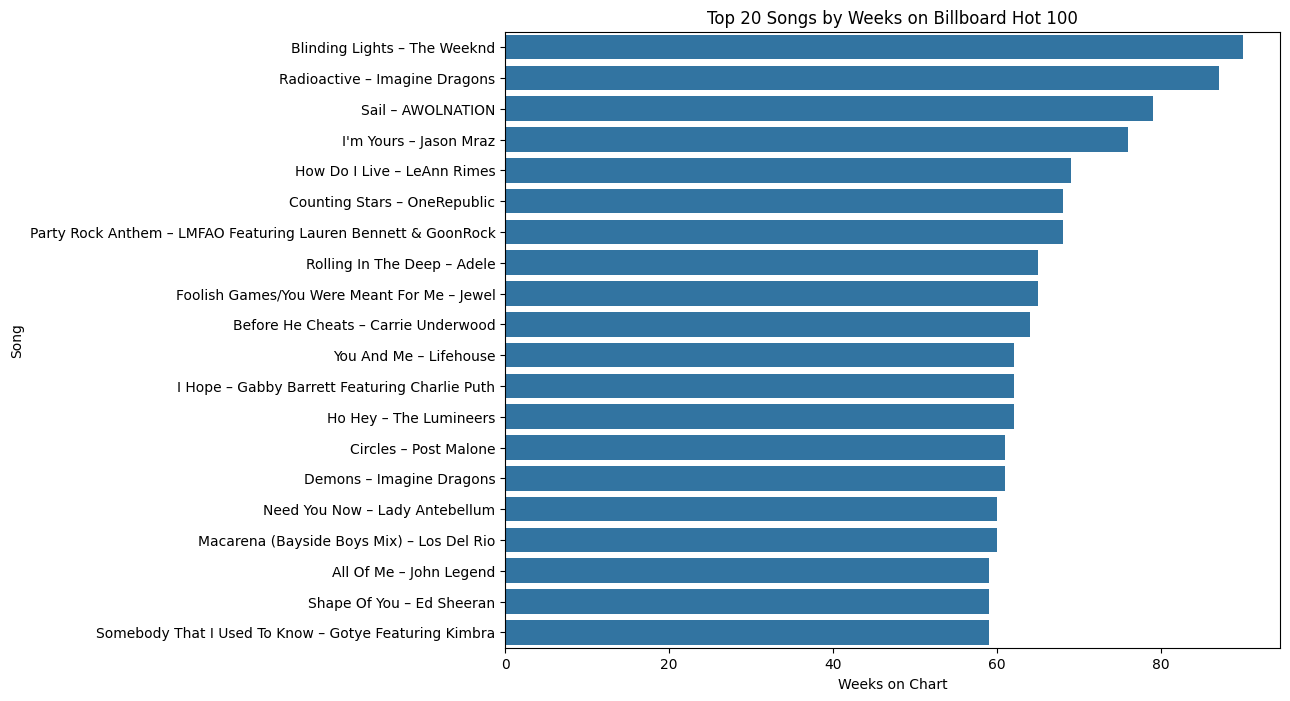

,date,rank,song,artist,last_week,peak_rank,weeks_on_board,year,month,decade,is_collab
919,2021-09-04,20,Blinding Lights,The Weeknd,21.0,1,90,2021,9,2020,0
39148,2014-05-10,49,Radioactive,Imagine Dragons,48.0,3,87,2014,5,2010,0
39844,2014-03-22,45,Sail,AWOLNATION,41.0,17,79,2014,3,2010,0
63047,2009-10-10,48,I'm Yours,Jason Mraz,49.0,6,76,2009,10,2000,0
120444,1998-10-10,45,How Do I Live,LeAnn Rimes,48.0,2,69,1998,10,1990,0
36849,2014-10-18,50,Counting Stars,OneRepublic,47.0,2,68,2014,10,2010,0
48548,2012-07-21,49,Party Rock Anthem,LMFAO Featuring Lauren Bennett & GoonRock,50.0,1,68,2012,7,2010,1
49948,2012-04-14,49,Rolling In The Deep,Adele,43.0,1,65,2012,4,2010,0
123746,1998-02-21,47,Foolish Games/You Were Meant For Me,Jewel,42.0,2,65,1998,2,1990,0
72746,2007-12-01,47,Before He Cheats,Carrie Underwood,43.0,8,64,2007,12,2000,0


In [ ]:
top_longevity = (
    df.sort_values("weeks_on_board", ascending=False)
      .drop_duplicates(subset=["song", "artist"])
      .head(20)
)

plt.figure(figsize=(10,8))
sns.barplot(
    data=top_longevity,
    x="weeks_on_board",
    y=top_longevity["song"] + " – " + top_longevity["artist"]
)
plt.title("Top 20 Songs by Weeks on Billboard Hot 100")
plt.xlabel("Weeks on Chart")
plt.ylabel("Song")
plt.show()

display(top_longevity)


9. Rank vs. Longevity Scatter Plot

   Do higher-ranked songs last longer? Yes the do and the scatter shows it.

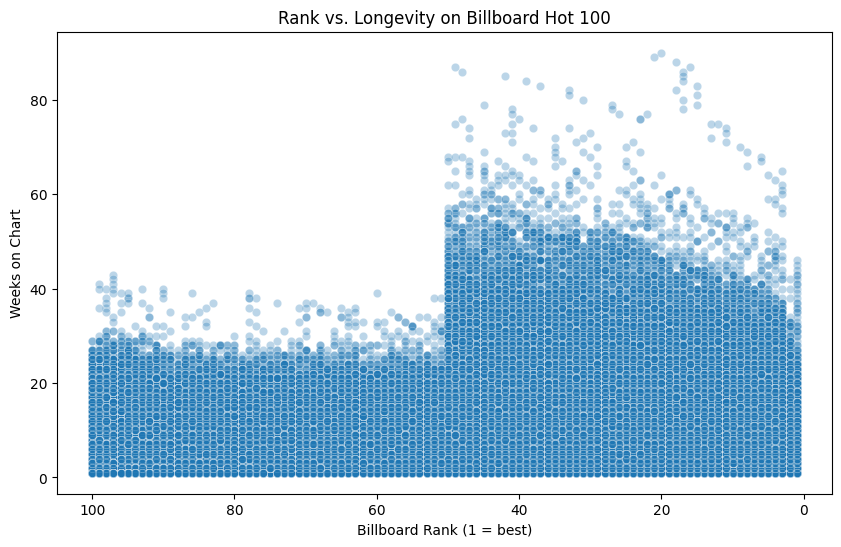

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="rank", y="weeks_on_board", alpha=0.3)
plt.gca().invert_xaxis()  # rank 1 on left
plt.title("Rank vs. Longevity on Billboard Hot 100")
plt.xlabel("Billboard Rank (1 = best)")
plt.ylabel("Weeks on Chart")
plt.show()


10. TikTok Era Analysis (Post-2016)

    Works great with the dataset as since songs exploded after streaming.

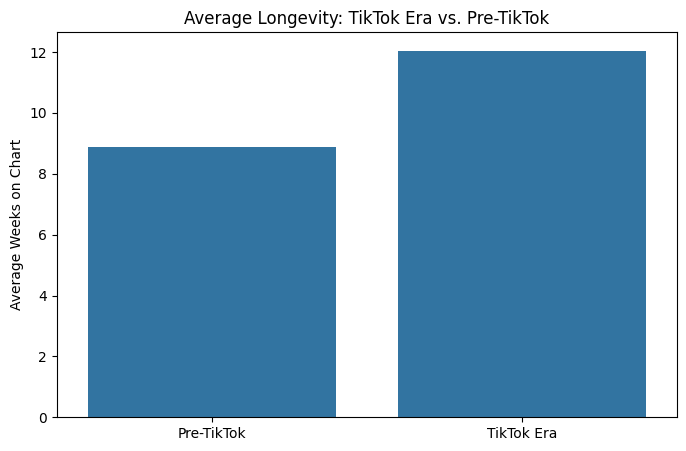

In [ ]:
df["era"] = np.where(df["year"] >= 2016, "TikTok Era", "Pre-TikTok")

era_compare = df.groupby("era")["weeks_on_board"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=era_compare, x="era", y="weeks_on_board")
plt.title("Average Longevity: TikTok Era vs. Pre-TikTok")
plt.xlabel("")
plt.ylabel("Average Weeks on Chart")
plt.show()


Predictive Modeling – Can We Predict a Hit?

1. Prepare ML Dataset

In [ ]:
df_ml = df[[
    "rank",
    "last_week",
    "peak_rank",
    "weeks_on_board",
    "is_collab",
    "year",
    "decade"
]].copy()

# Replace missing last_week with 101 (meaning: not on chart last week)
df_ml["last_week"] = df_ml["last_week"].fillna(101)

# Peek
df_ml.head()


,rank,last_week,peak_rank,weeks_on_board,is_collab,year,decade
0,1,1.0,1,3,0,2021,2020
1,2,2.0,1,16,1,2021,2020
2,3,3.0,1,14,1,2021,2020
3,4,4.0,3,19,0,2021,2020
4,5,5.0,2,18,0,2021,2020



2. Regression Model
   Predict: How long will a song stay on the chart?

   Model: Random Forest Regressor

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df_ml.drop("weeks_on_board", axis=1)
y = df_ml["weeks_on_board"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, preds))
print("R2:", r2_score(y_test, preds))


MSE: 16.246492560316668
R2: 0.7161528372029253



3. Feature Importance Visualization


/tmp/ipython-input-48125161.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feat_names, palette="viridis")


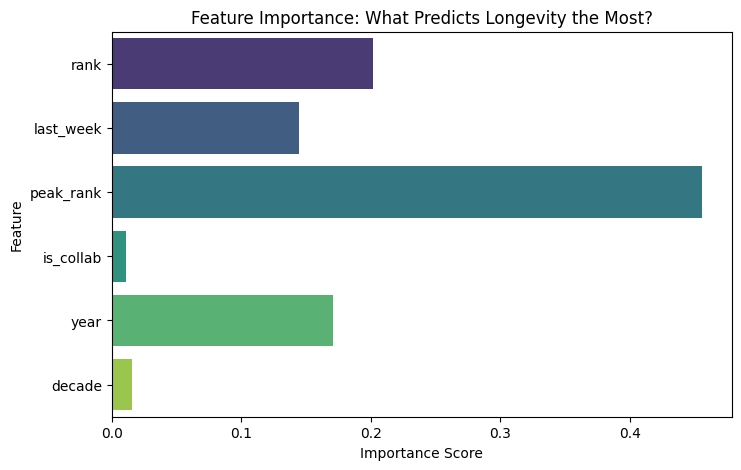

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feat_names = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feat_names, palette="viridis")
plt.title("Feature Importance: What Predicts Longevity the Most?")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()



4. Classification Model (Decision Tree)
   Predict: Will a song last 20+ weeks on the charts?


In [ ]:
df_ml["long_hit"] = (df_ml["weeks_on_board"] >= 20).astype(int)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# New feature/target split
X_cls = df_ml.drop(["weeks_on_board", "long_hit"], axis=1)
y_cls = df_ml["long_hit"]

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Train model
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_c, y_train_c)

# Predictions
pred_c = dt.predict(X_test_c)

# Evaluation
print("Accuracy:", accuracy_score(y_test_c, pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, pred_c))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_c, pred_c))


Accuracy: 0.9362143657790299

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     60567
           1       0.72      0.37      0.49      5451

    accuracy                           0.94     66018
   macro avg       0.83      0.68      0.73     66018
weighted avg       0.93      0.94      0.93     66018


Confusion Matrix:
 [[59771   796]
 [ 3415  2036]]



5. Visualize the Decision Tree


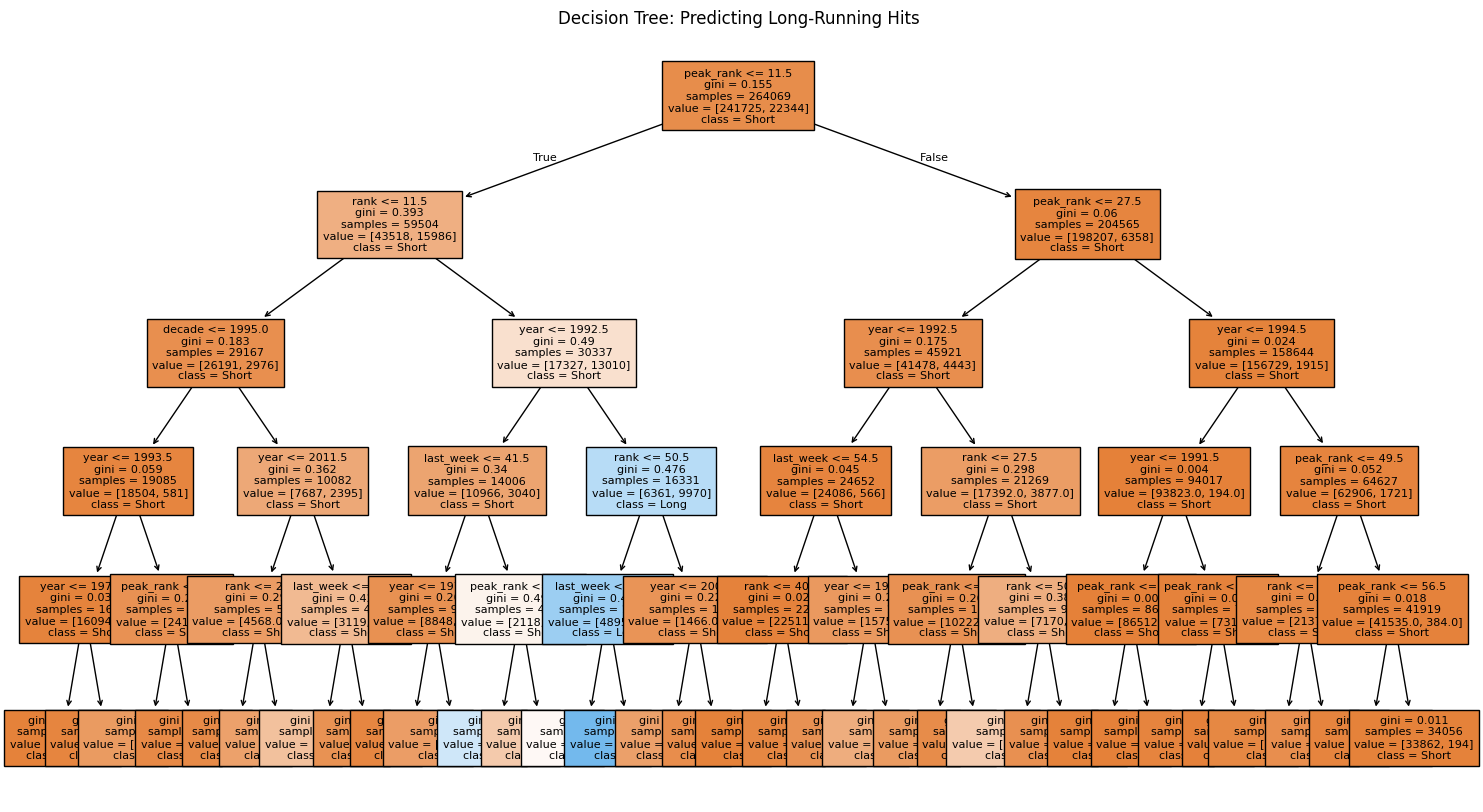

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(dt, feature_names=X_cls.columns, class_names=["Short", "Long"], filled=True, fontsize=8)
plt.title("Decision Tree: Predicting Long-Running Hits")
plt.show()


Part 1 - Integrate US GDP into Billboard Analysis

1.1 Load and reshape the GDP data

In [ ]:
# ============================================
# A. LOAD & PREPARE GDP DATA (NATIONAL LEVEL)
# ============================================
gdp_raw = pd.read_csv('/content/SAGDP2N__ALL_AREAS_1997_2020.csv')

# Filter to United States total GDP across all industries
gdp_us = gdp_raw[
    (gdp_raw["GeoName"] == "United States *") &
    (gdp_raw["Description"] == "All industry total")
].copy()

# Years available in this file
gdp_years = [str(y) for y in range(1997, 2021)]

# Make sure year columns are numeric
gdp_us[gdp_years] = gdp_us[gdp_years].apply(pd.to_numeric, errors="coerce")

# Long format: one row per year
gdp_long = gdp_us.melt(
    value_vars=gdp_years,
    var_name="year",
    value_name="gdp"
)

# Clean types
gdp_long["year"] = gdp_long["year"].astype(int)
gdp_long["gdp_growth"] = gdp_long["gdp"].pct_change() * 100  # % growth vs previous year

gdp_long.head()


,year,gdp,gdp_growth
0,1997,8577552.0,NaN
1,1998,9062817.0,5.657383
2,1999,9630663.0,6.265668
3,2000,10252347.0,6.455257
4,2001,10581822.0,3.213654


1.2 Merge GDP with your Billboard dataframe

In [ ]:
# ============================================
# B. MERGE GDP INTO BILLBOARD DATA
# ============================================

# Make sure df has 'year' already (from date)
df["year"] = df["date"].dt.year

df = df.merge(
    gdp_long[["year", "gdp", "gdp_growth"]],
    on="year",
    how="left"
)

df[["year", "gdp", "gdp_growth"]].head()


,year,gdp,gdp_growth
0,2021,NaN,NaN
1,2021,NaN,NaN
2,2021,NaN,NaN
3,2021,NaN,NaN
4,2021,NaN,NaN


1.3 Example GDP + Billboard visualizations

1) GDP vs Average Song Longevity

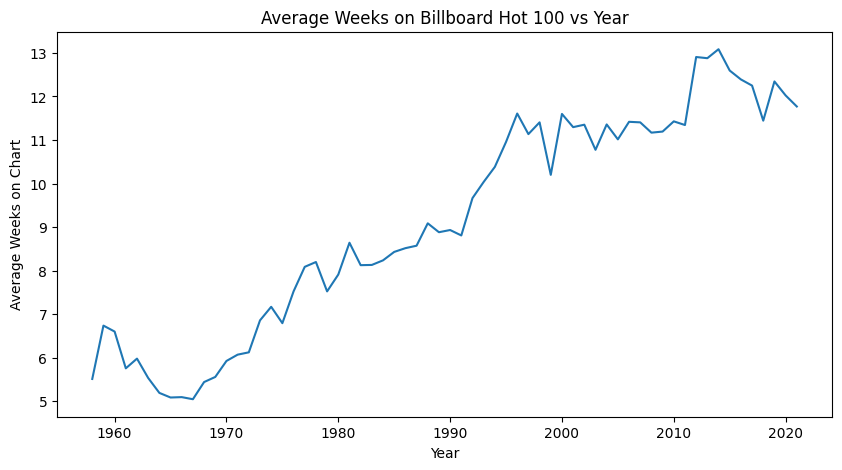

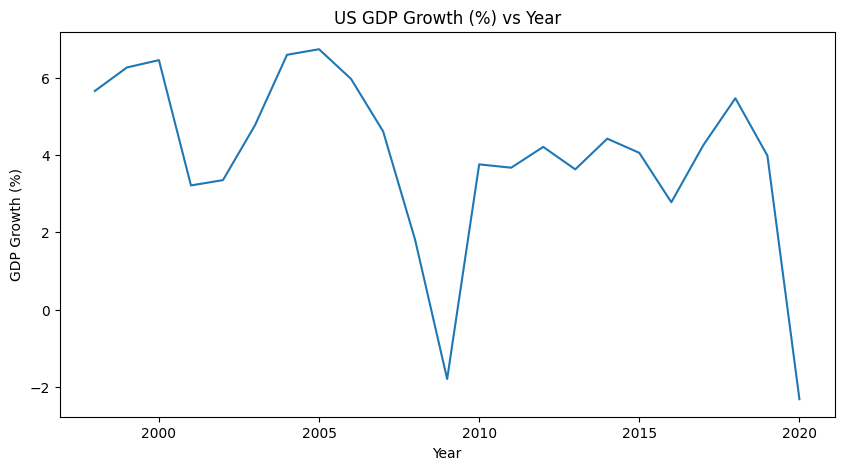

In [ ]:
# Average weeks on chart per year + GDP
yearly_combo = (
    df.groupby("year")[["weeks_on_board", "gdp", "gdp_growth"]]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_combo, x="year", y="weeks_on_board")
plt.title("Average Weeks on Billboard Hot 100 vs Year")
plt.xlabel("Year")
plt.ylabel("Average Weeks on Chart")
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_combo, x="year", y="gdp_growth")
plt.title("US GDP Growth (%) vs Year")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.show()


2) Direct relationship: GDP growth vs longevity

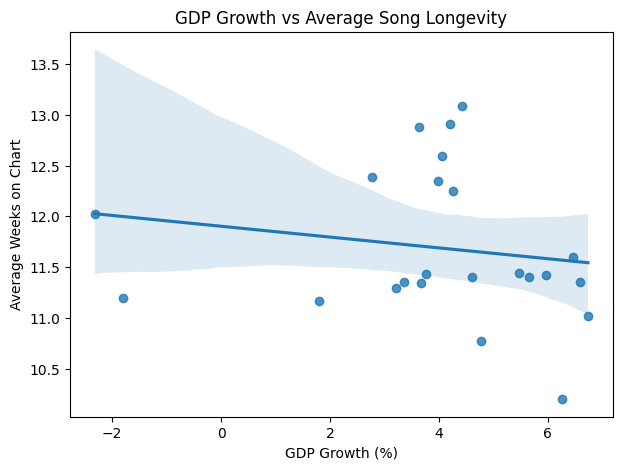

In [ ]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=yearly_combo.dropna(subset=["gdp_growth", "weeks_on_board"]),
    x="gdp_growth",
    y="weeks_on_board"
)
plt.title("GDP Growth vs Average Song Longevity")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Average Weeks on Chart")
plt.show()


Part 2 - Integrate Spotify Mood / Audio Features

2.1 Load and clean the Spotify dataset

In [ ]:
# ============================================
# C. LOAD & PREPARE SPOTIFY AUDIO FEATURES
# ============================================
spotify = pd.read_csv('/content/data.csv')

# Keep only useful columns
spotify_small = spotify[[
    "name", "artists", "year",
    "valence", "energy", "danceability",
    "tempo", "acousticness"
]].copy()

# Clean song name
spotify_small["song_clean"] = spotify_small["name"].str.lower().str.strip()

# Extract a primary artist (first in the list)
spotify_small["primary_artist"] = (
    spotify_small["artists"]
      .astype(str)
      .str.strip("[]")
      .str.split(",")
      .str[0]
      .str.replace("'", "")
      .str.replace('"', "")
      .str.strip()
)

spotify_small.head()


,name,artists,year,valence,energy,danceability,tempo,acousticness,song_clean,primary_artist
0,Singende Bataillone 1. Teil,['Carl Woitschach'],1928,0.7790,0.1950,0.708,118.469,0.995,singende bataillone 1. teil,Carl Woitschach
1,"Fantasiestücke, Op. 111: Più tosto lento","['Robert Schumann', 'Vladimir Horowitz']",1928,0.0767,0.0135,0.379,83.972,0.994,"fantasiestücke, op. 111: più tosto lento",Robert Schumann
2,Chapter 1.18 - Zamek kaniowski,['Seweryn Goszczyński'],1928,0.8800,0.2200,0.749,107.177,0.604,chapter 1.18 - zamek kaniowski,Seweryn Goszczyński
3,Bebamos Juntos - Instrumental (Remasterizado),['Francisco Canaro'],1928,0.7200,0.1300,0.781,108.003,0.995,bebamos juntos - instrumental (remasterizado),Francisco Canaro
4,"Polonaise-Fantaisie in A-Flat Major, Op. 61","['Frédéric Chopin', 'Vladimir Horowitz']",1928,0.0693,0.2040,0.210,62.149,0.990,"polonaise-fantaisie in a-flat major, op. 61",Frédéric Chopin


2.2 Create matching keys on the Billboard side

In [ ]:
# ============================================
# D. CREATE MATCH KEYS ON BILLBOARD DATA
# ============================================

# Cleaned song name
df["song_clean"] = df["song"].str.lower().str.strip()

# Year column should already exist; if not:
# df["year"] = df["date"].dt.year

df[["song", "song_clean", "year"]].head()


,song,song_clean,year
0,Easy On Me,easy on me,2021
1,Stay,stay,2021
2,Industry Baby,industry baby,2021
3,Fancy Like,fancy like,2021
4,Bad Habits,bad habits,2021


2.3 Merge Spotify mood features into Billboard

In [ ]:
# ============================================
# E. MERGE SPOTIFY FEATURES INTO BILLBOARD DATA
# ============================================

df = df.merge(
    spotify_small[[
        "song_clean", "year",
        "valence", "energy", "danceability",
        "tempo", "acousticness"
    ]],
    on=["song_clean", "year"],
    how="left",
    suffixes=("", "_spotify")
)

# Check match rate
matched = df["valence"].notna().mean()
print(f"Share of Billboard rows with Spotify mood match: {matched:.1%}")

df[["song", "artist", "year", "valence", "energy", "danceability"]].head()


Share of Billboard rows with Spotify mood match: 36.8%


,song,artist,year,valence,energy,danceability
0,Easy On Me,Adele,2021,NaN,NaN,NaN
1,Stay,The Kid LAROI & Justin Bieber,2021,NaN,NaN,NaN
2,Industry Baby,Lil Nas X & Jack Harlow,2021,NaN,NaN,NaN
3,Fancy Like,Walker Hayes,2021,NaN,NaN,NaN
4,Bad Habits,Ed Sheeran,2021,NaN,NaN,NaN


2.4 Example “Mood of America” visualizations

1) Average valence (happiness) by year

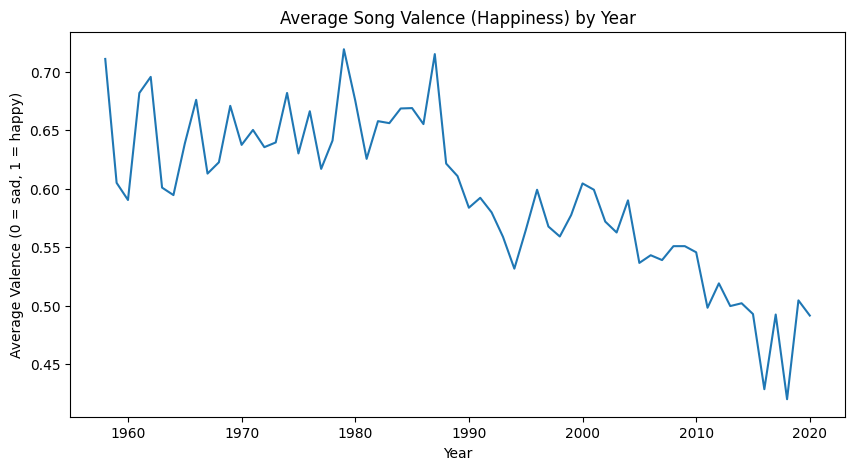

In [ ]:
mood_yearly = (
    df.groupby("year")["valence"]
      .mean()
      .reset_index()
      .dropna()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=mood_yearly, x="year", y="valence")
plt.title("Average Song Valence (Happiness) by Year")
plt.xlabel("Year")
plt.ylabel("Average Valence (0 = sad, 1 = happy)")
plt.show()


2) Mood vs Longevity: Are happier songs staying longer?

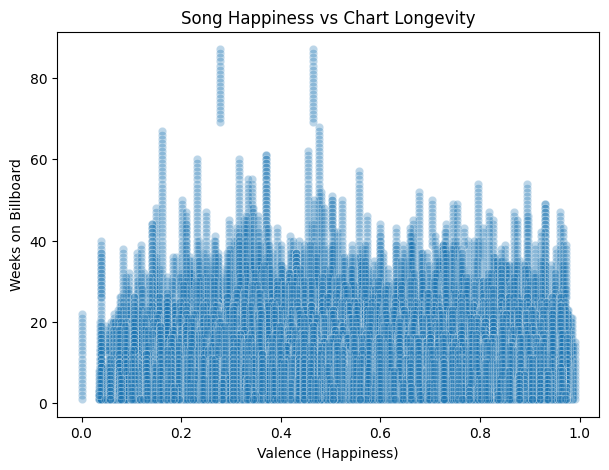

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df.dropna(subset=["valence", "weeks_on_board"]),
    x="valence",
    y="weeks_on_board",
    alpha=0.3
)
plt.title("Song Happiness vs Chart Longevity")
plt.xlabel("Valence (Happiness)")
plt.ylabel("Weeks on Billboard")
plt.show()


3) Era comparison: pre-TikTok vs TikTok era mood

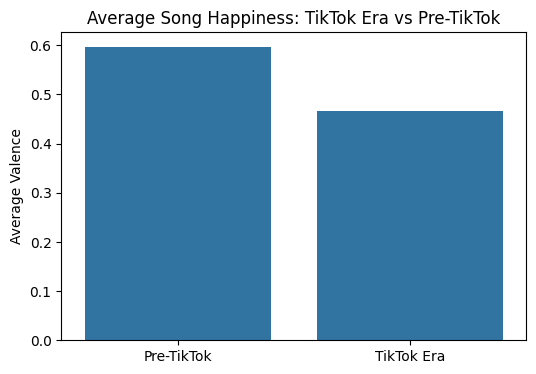

In [ ]:
df["era"] = np.where(df["year"] >= 2016, "TikTok Era", "Pre-TikTok")

era_mood = (
    df.groupby("era")["valence"]
      .mean()
      .reset_index()
      .dropna()
)

plt.figure(figsize=(6,4))
sns.barplot(data=era_mood, x="era", y="valence")
plt.title("Average Song Happiness: TikTok Era vs Pre-TikTok")
plt.xlabel("")
plt.ylabel("Average Valence")
plt.show()


STEP 1 - Add Crisis Markers to Billboard Data

In [ ]:
# ============================================
# MARK HISTORICAL CRISIS YEARS
# ============================================

# Source: NBER U.S. recessions + major conflicts after 1958
recession_years = [
    1960, 1970, 1974, 1975,
    1980, 1981, 1982,
    1990, 1991,
    2001,
    2008, 2009,
    2020
]

# Vietnam War (peak US involvement 1965–1973)
vietnam_years = list(range(1965, 1974))

# Gulf War
gulf_war_years = [1990, 1991]

# COVID
covid_years = [2020, 2021]

def mark_crisis(year):
    if year in recession_years:
        return "Recession"
    if year in vietnam_years:
        return "Vietnam War"
    if year in gulf_war_years:
        return "Gulf War"
    if year in covid_years:
        return "COVID-19"
    return "Normal"

df["crisis_period"] = df["year"].apply(mark_crisis)

df[["year", "crisis_period"]].head(20)


,year,crisis_period
0,2021,COVID-19
1,2021,COVID-19
2,2021,COVID-19
3,2021,COVID-19
4,2021,COVID-19
5,2021,COVID-19
6,2021,COVID-19
7,2021,COVID-19
8,2021,COVID-19
9,2021,COVID-19


STEP 2 - Extract Top Songs for Each Year

In [ ]:
# TOP SONG OF EACH YEAR
top_song_yearly = (
    df.sort_values(["year", "rank"])
      .groupby("year")
      .first()
      [["song", "artist", "valence", "energy", "acousticness"]]
      .reset_index()
)

top_song_yearly.head()


,year,song,artist,valence,energy,acousticness
0,1958,The Chipmunk Song,The Chipmunks With David Seville,0.458,0.144,0.80600
1,1959,Why,Frankie Avalon,0.608,0.460,0.17500
2,1960,Are You Lonesome To-night?,Elvis Presley With The Jordanaires,0.296,0.257,0.88200
3,1961,The Lion Sleeps Tonight,The Tokens,0.967,0.776,0.72900
4,1962,Telstar,The Tornadoes,0.629,0.751,0.00252


STEP 3 - Compare Mood in Crisis Years vs Normal Years

In [ ]:
mood_comparison = (
    df.groupby("crisis_period")[["valence", "energy", "acousticness"]]
      .mean()
      .reset_index()
)

mood_comparison


,crisis_period,valence,energy,acousticness
0,COVID-19,NaN,NaN,NaN
1,Normal,0.567056,0.648005,0.219026
2,Recession,0.598924,0.626726,0.245879
3,Vietnam War,0.642029,0.506296,0.457413


STEP 4 - Visualize Mood Difference in Crisis Years

Valence (Sad ↔ Happy)

/tmp/ipython-input-3272345959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mood_comparison, x="crisis_period", y="valence", palette="coolwarm")


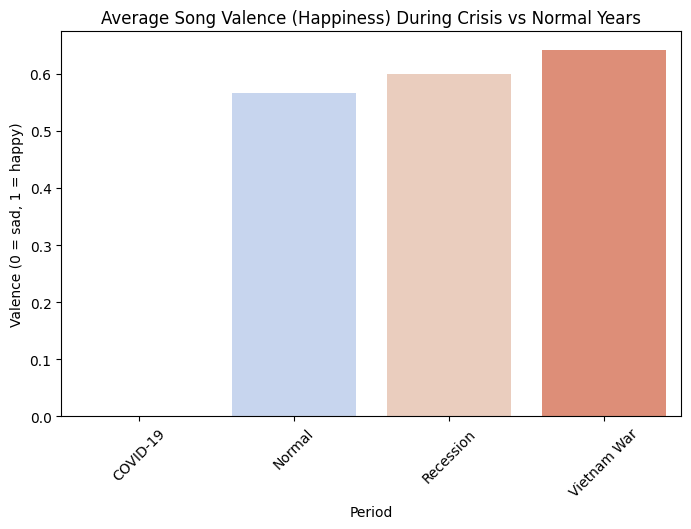

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=mood_comparison, x="crisis_period", y="valence", palette="coolwarm")
plt.title("Average Song Valence (Happiness) During Crisis vs Normal Years")
plt.xlabel("Period")
plt.ylabel("Valence (0 = sad, 1 = happy)")
plt.xticks(rotation=45)
plt.show()


Acousticness (Softer, Sadder, Emotional Songs)

/tmp/ipython-input-4195206264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mood_comparison, x="crisis_period", y="acousticness", palette="magma")


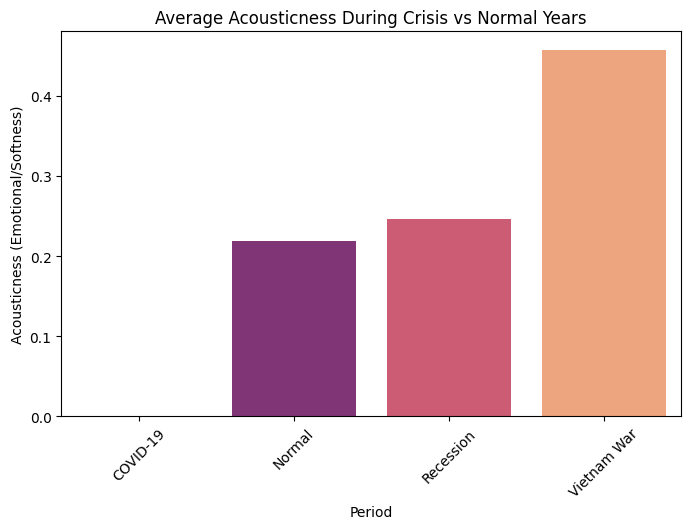

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=mood_comparison, x="crisis_period", y="acousticness", palette="magma")
plt.title("Average Acousticness During Crisis vs Normal Years")
plt.xlabel("Period")
plt.ylabel("Acousticness (Emotional/Softness)")
plt.xticks(rotation=45)
plt.show()


STEP 5 - Visualize Top Song Mood During Each Crisis

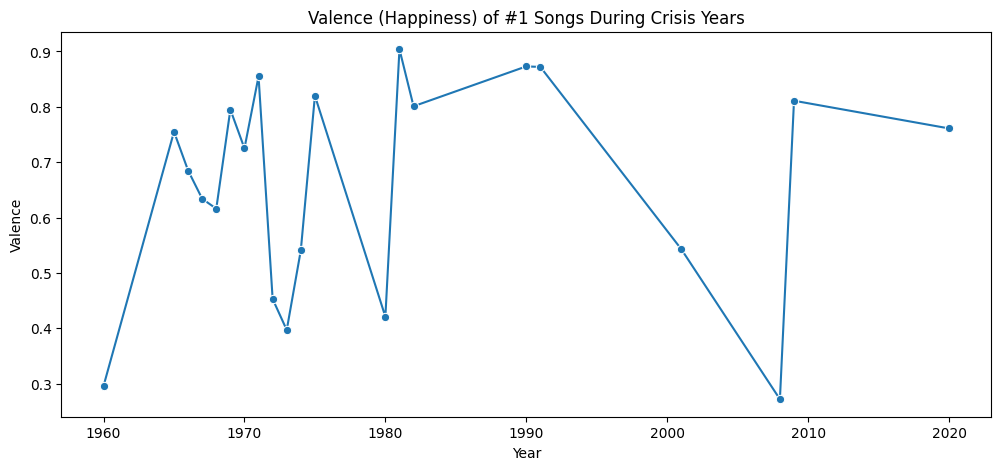

In [ ]:
crisis_top_songs = top_song_yearly[top_song_yearly["year"].isin(recession_years + vietnam_years + gulf_war_years + covid_years)]

plt.figure(figsize=(12,5))
sns.lineplot(data=crisis_top_songs, x="year", y="valence", marker="o")
plt.title("Valence (Happiness) of #1 Songs During Crisis Years")
plt.xlabel("Year")
plt.ylabel("Valence")
plt.show()


In [ ]:
# 1) Collaboration shares (uses collab_yearly)
collab_yearly = (
    df.groupby("year")["is_collab"]
      .mean()
      .reset_index()
      .rename(columns={"is_collab": "collab_rate"})
)
collab_yearly["collab_percent"] = collab_yearly["collab_rate"] * 100

# Early vs recent: first 10 years vs last 10 years in the dataset
early_share = collab_yearly.head(10)["collab_percent"].mean()
recent_share = collab_yearly.tail(10)["collab_percent"].mean()

print("Early years collab share (%):", round(early_share, 1))
print("Recent years collab share (%):", round(recent_share, 1))

# 2) Top artist unique song count (uses artist_song_counts)
artist_song_counts = (
    df.groupby("artist")["song"]
      .nunique()
      .reset_index()
      .rename(columns={"song": "unique_songs"})
)

top_count = artist_song_counts["unique_songs"].max()
top_artist = artist_song_counts.loc[artist_song_counts["unique_songs"].idxmax(), "artist"]

print("Top artist:", top_artist)
print("Top artist unique songs:", int(top_count))

Early years collab share (%): 6.5
Recent years collab share (%): 15.7
Top artist: Glee Cast
Top artist unique songs: 183


In [ ]:
yearly_combo = (
    df.groupby("year")[["weeks_on_board", "gdp", "gdp_growth"]]
      .mean()
      .reset_index()
)

# 1) GDP growth range
gdp_min = yearly_combo["gdp_growth"].min()
gdp_max = yearly_combo["gdp_growth"].max()
print("GDP growth range: ", round(gdp_min, 2), "to", round(gdp_max, 2), "%")

# 2) Avg weeks in high vs low/negative growth years
high = yearly_combo[yearly_combo["gdp_growth"] > 0]["weeks_on_board"].mean()
low = yearly_combo[yearly_combo["gdp_growth"] <= 0]["weeks_on_board"].mean()
print("Avg weeks, positive GDP years:", round(high, 2))
print("Avg weeks, zero/negative GDP years:", round(low, 2))

# 3) Correlation
corr = yearly_combo["gdp_growth"].corr(yearly_combo["weeks_on_board"])
print("Correlation (GDP growth vs avg weeks):", round(corr, 2))


GDP growth range:  -2.32 to 6.74 %
Avg weeks, positive GDP years: 11.69
Avg weeks, zero/negative GDP years: 11.74
Correlation (GDP growth vs avg weeks): -0.21


In [ ]:
# Crisis vs normal using the full df
normal = df[df["crisis_period"] == "Normal"]
crisis = df[df["crisis_period"] != "Normal"]

val_normal = normal["valence"].mean()
val_crisis = crisis["valence"].mean()

acoustic_normal = normal["acousticness"].mean()
acoustic_crisis = crisis["acousticness"].mean()

print("Average Valence - Normal Years:", round(val_normal, 2))
print("Average Valence - Crisis Years:", round(val_crisis, 2))
print("Average Acousticness - Normal Years:", round(acoustic_normal, 2))
print("Average Acousticness - Crisis Years:", round(acoustic_crisis, 2))


Average Valence - Normal Years: 0.57
Average Valence - Crisis Years: 0.62
Average Acousticness - Normal Years: 0.22
Average Acousticness - Crisis Years: 0.33


In [ ]:
# Top songs during crisis years
crisis_top_songs = top_song_yearly[top_song_yearly["year"].isin(
    recession_years + vietnam_years + gulf_war_years + covid_years
)]

# Top 15
crisis_top_songs.sort_values("year").head(15)


,year,song,artist,valence,energy,acousticness
2,1960,Are You Lonesome To-night?,Elvis Presley With The Jordanaires,0.296,0.257,0.8820
7,1965,Over And Over,The Dave Clark Five,0.755,0.818,0.1350
8,1966,I'm A Believer,The Monkees,0.685,0.293,0.6170
9,1967,Hello Goodbye,The Beatles,0.634,0.655,0.0330
10,1968,I Heard It Through The Grapevine,Marvin Gaye,0.616,0.362,0.2720
11,1969,Someday We'll Be Together,Diana Ross & The Supremes,0.795,0.535,0.1400
12,1970,My Sweet Lord/Isn't It A Pity,George Harrison,0.725,0.600,0.2360
13,1971,Brand New Key,Melanie,0.855,0.292,0.8050
14,1972,Me And Mrs. Jones,Billy Paul,0.453,0.528,0.2340
15,1973,Time In A Bottle,Jim Croce,0.397,0.398,0.5440


In [ ]:
print("Accuracy:", accuracy_score(y_test_c, pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, pred_c))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_c, pred_c))


Accuracy: 0.9362143657790299

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     60567
           1       0.72      0.37      0.49      5451

    accuracy                           0.94     66018
   macro avg       0.83      0.68      0.73     66018
weighted avg       0.93      0.94      0.93     66018


Confusion Matrix:
 [[59771   796]
 [ 3415  2036]]


In [ ]:
# Songs per year range
songs_per_year = df.groupby("year")["song"].count().reset_index()
min_songs = songs_per_year["song"].min()
max_songs = songs_per_year["song"].max()
print("Min songs per year:", int(min_songs))
print("Max songs per year:", int(max_songs))

# Average weeks_on_board range
yearly_weeks = df.groupby("year")["weeks_on_board"].mean().reset_index()
min_weeks = yearly_weeks["weeks_on_board"].min()
max_weeks = yearly_weeks["weeks_on_board"].max()
print("Min avg weeks on chart:", round(min_weeks, 1))
print("Max avg weeks on chart:", round(max_weeks, 1))


Min songs per year: 2226
Max songs per year: 6434
Min avg weeks on chart: 5.2
Max avg weeks on chart: 13.1
